# PPG Baseline Denoising and HR Evaluation on DATABASE

This Jupyternotebook uses the `DATABASE` dataset and the baseline script `ppg_fft_hr_analysis.py` to accomplish three things:

1. Provide tables of `avAE`, `avRE`, and `sdAE` metrics.

2. Compare the unfiltered PPG signal with the baseline-preprocessed PPG signal.

3. Plot the time series, correlation, and Bland-Altman plots of the PPG FFT-estimated heart rate versus the `BPM0` golden heart rate.

The baseline preprocessing here is defined as follows: PPG1/PPG2 are subjected to 0.4–4 Hz fourth-order Butterworth bandpass filtering and z-score normalization, and then averaged.

In [1]:
from pathlib import Path
import os
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

WORKSPACE = Path("/Users/xiongzaizai/Documents/PPG")
SCRIPTS = WORKSPACE / "scripts"
DATA_DIR = Path("/Users/xiongzaizai/PPG/DATABASE")
OUTDIR = WORKSPACE / "outputs_ppg_denosing_notebook"
PLOTS_DIR = OUTDIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(SCRIPTS))

print("DATABASE:", DATA_DIR, "exists =", DATA_DIR.exists())
print("Output:", OUTDIR)

DATABASE: /Users/xiongzaizai/PPG/DATABASE exists = True
Output: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denosing_notebook


## 1. Run DATABASE version PPG FFT baseline

This unit calls `scripts/ppg_fft_hr_analysis.py`. The script has been changed to read the `DATABASE` dataset by default and use `BPM0` as the ground truth.

In [2]:
cmd = [
    sys.executable,
    str(SCRIPTS / "ppg_fft_hr_analysis.py"),
    "--data-dir", str(DATA_DIR),
    "--records", "all",
    "--outdir", str(OUTDIR),
    "--window-sec", "8",
    "--step-sec", "2",
    "--n-fft", "4096",
    "--search-low-hz", "0.8",
    "--search-high-hz", "3.0",
    "--ppg-low-hz", "0.4",
    "--ppg-high-hz", "4.0",
    "--smooth-windows", "5",
    "--plot-records", "DATA_01_TYPE01", "DATA_08_TYPE02", "TEST_S01_T01", "TEST_S07_T02",
]

env = os.environ.copy()
env["MPLCONFIGDIR"] = str(WORKSPACE / ".mplconfig")
result = subprocess.run(cmd, cwd=str(WORKSPACE), env=env, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
print(result.stdout[-5000:])
if result.returncode != 0:
    raise RuntimeError(f"Baseline script failed with exit code {result.returncode}")

Wrote windows: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denosing_notebook/ppg_fft_hr_windows.csv
Wrote metrics: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denosing_notebook/ppg_fft_metrics.csv
Plots:
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denosing_notebook/plots/DATA_01_TYPE01_timeseries_ppg_fft_vs_bpm0.png
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denosing_notebook/plots/DATA_08_TYPE02_timeseries_ppg_fft_vs_bpm0.png
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denosing_notebook/plots/TEST_S01_T01_timeseries_ppg_fft_vs_bpm0.png
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denosing_notebook/plots/TEST_S07_T02_timeseries_ppg_fft_vs_bpm0.png
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denosing_notebook/plots/scatter_ppg_fft_vs_bpm0.png
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denosing_notebook/plots/bland_altman_ppg_fft_vs_bpm0.png
         record       split  method  n_windows  n_valid   mae_bpm  std_error_bpm  std_abs_error_bpm  mean_relative_error_percen

## 2. avAE, avRE, sdAE table


- `avAE`: average absolute error, in bpm。
- `avRE`: average relative absolute error, in %。
- `sdAE`: standard deviation of absolute error, in bpm。

In [3]:
windows = pd.read_csv(OUTDIR / "ppg_fft_hr_windows.csv")
metrics = pd.read_csv(OUTDIR / "ppg_fft_metrics.csv")

metric_table = metrics.loc[
    metrics["record"].str.startswith("ALL_"),
    ["record", "split", "method", "n_valid", "mae_bpm", "mean_relative_error_percent", "std_abs_error_bpm"],
].copy()

metric_table = metric_table.rename(columns={
    "mae_bpm": "avAE_bpm",
    "mean_relative_error_percent": "avRE_percent",
    "std_abs_error_bpm": "sdAE_bpm",
})
metric_table = metric_table.round({
    "avAE_bpm": 3,
    "avRE_percent": 3,
    "sdAE_bpm": 3,
})

metric_table.to_csv(OUTDIR / "ppg_fft_avAE_avRE_sdAE_table.csv", index=False)
display(metric_table)
print("Saved:", OUTDIR / "ppg_fft_avAE_avRE_sdAE_table.csv")

,record,split,method,n_valid,avAE_bpm,avRE_percent,sdAE_bpm
22,ALL_training,training,PPG FFT,1768,10.504,7.833,15.551
23,ALL_competition,competition,PPG FFT,1328,15.167,13.131,17.003
24,ALL_DATABASE,all,PPG FFT,3096,12.504,10.105,16.350


Saved: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denosing_notebook/ppg_fft_avAE_avRE_sdAE_table.csv


## 3. Comparison of Unprocessed PPG and Baseline Preprocessed PPG

Here, a representative window is selected for time-domain signal comparison. The top image shows the original PPG1/PPG2 average signal; the bottom image shows the PPG signal after baseline preprocessing within the same window.

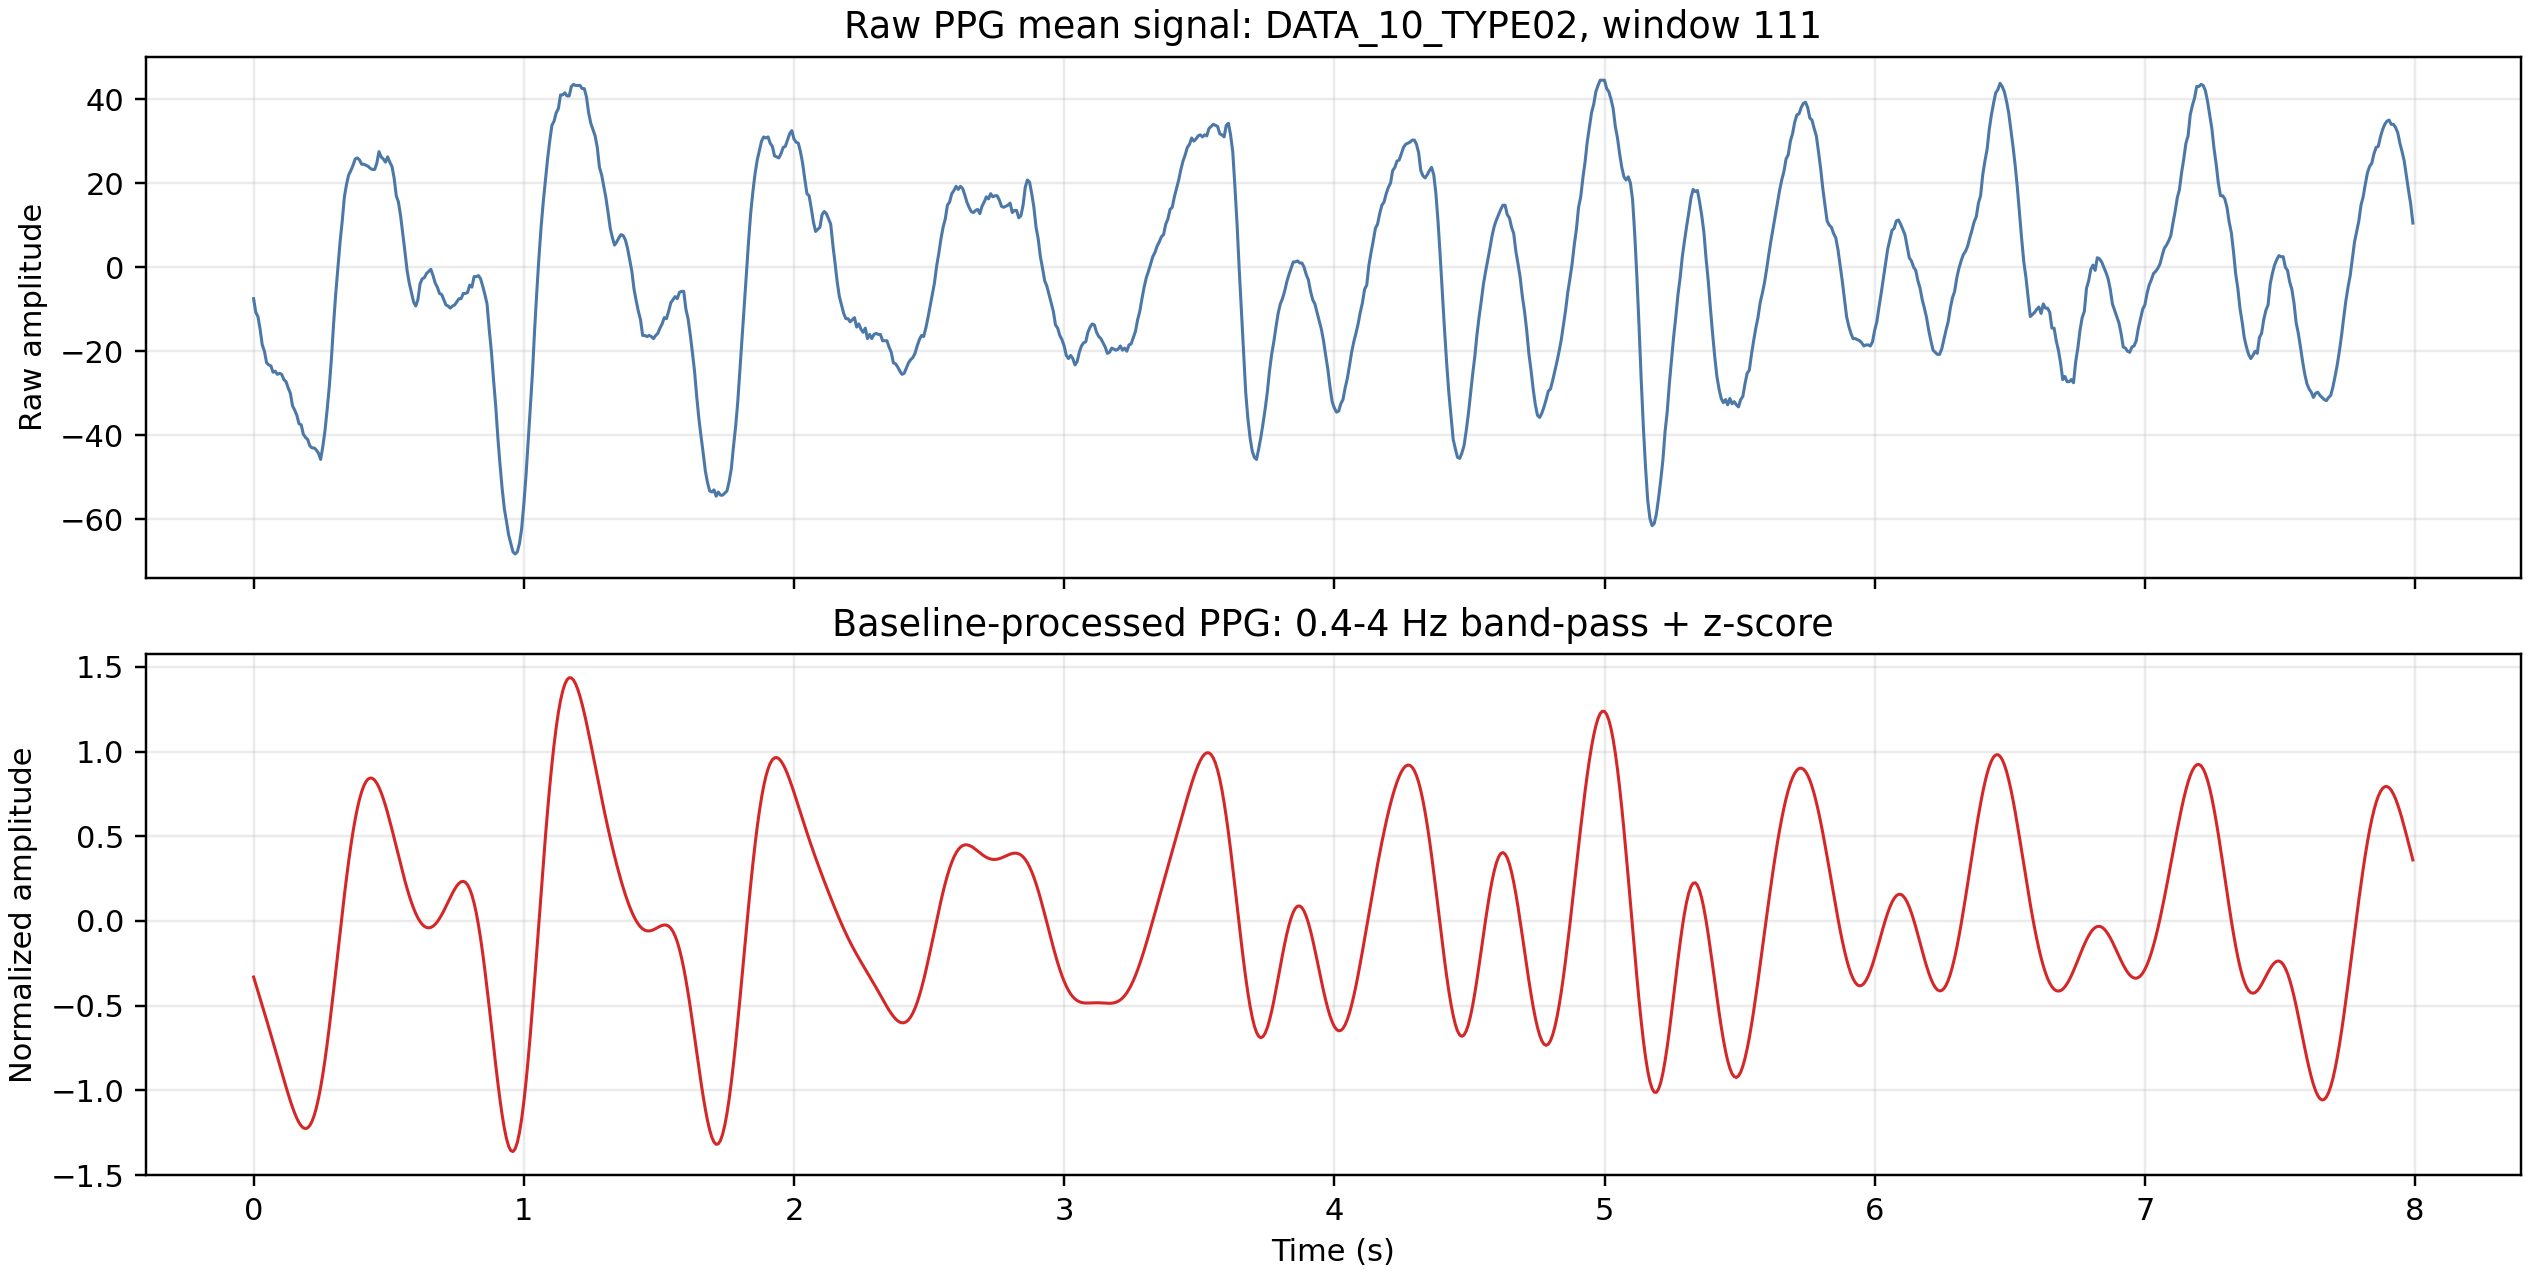

Saved: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denosing_notebook/plots/DATA_10_TYPE02_raw_vs_baseline_processed_ppg.png


In [4]:
from ppg_fft_hr_analysis import (
    discover_records,
    load_record,
    extract_ppg_channels,
    preprocess_ppg_window,
    zscore,
)

DEMO_RECORD = "DATA_10_TYPE02"
DEMO_WINDOW_INDEX = 111
FS = 125.0
WINDOW_SEC = 8.0
STEP_SEC = 2.0

record_map = {record.name: record for record in discover_records(DATA_DIR, ["all"])}
record = record_map[DEMO_RECORD]
sig, bpm0 = load_record(record)
ppg1, ppg2 = extract_ppg_channels(record, sig)

window_pts = int(round(WINDOW_SEC * FS))
step_pts = int(round(STEP_SEC * FS))
start = (DEMO_WINDOW_INDEX - 1) * step_pts
stop = start + window_pts
t = np.arange(window_pts) / FS

raw_ppg = 0.5 * ppg1[start:stop] + 0.5 * ppg2[start:stop]
ppg1_processed = preprocess_ppg_window(ppg1[start:stop], FS, low_hz=0.4, high_hz=4.0, order=4)
ppg2_processed = preprocess_ppg_window(ppg2[start:stop], FS, low_hz=0.4, high_hz=4.0, order=4)
processed_ppg = 0.5 * ppg1_processed + 0.5 * ppg2_processed

fig, axes = plt.subplots(2, 1, figsize=(11.5, 5.8), sharex=True, constrained_layout=True)
axes[0].plot(t, raw_ppg, color="#4c78a8", linewidth=1.0)
axes[0].set_title(f"Raw PPG mean signal: {DEMO_RECORD}, window {DEMO_WINDOW_INDEX}")
axes[0].set_ylabel("Raw amplitude")
axes[0].grid(True, alpha=0.25)

axes[1].plot(t, processed_ppg, color="#d62728", linewidth=1.0)
axes[1].set_title("Baseline-processed PPG: 0.4-4 Hz band-pass + z-score")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Normalized amplitude")
axes[1].grid(True, alpha=0.25)

raw_processed_path = PLOTS_DIR / f"{DEMO_RECORD}_raw_vs_baseline_processed_ppg.png"
fig.savefig(raw_processed_path, dpi=220)
plt.close(fig)

display(Image(filename=str(raw_processed_path), width=900))
print("Saved:", raw_processed_path)

## 4. Time Series Comparison with BPM0

This figure shows the changes in `BPM0` and the estimated heart rate using PPG FFT in each 8-second window.

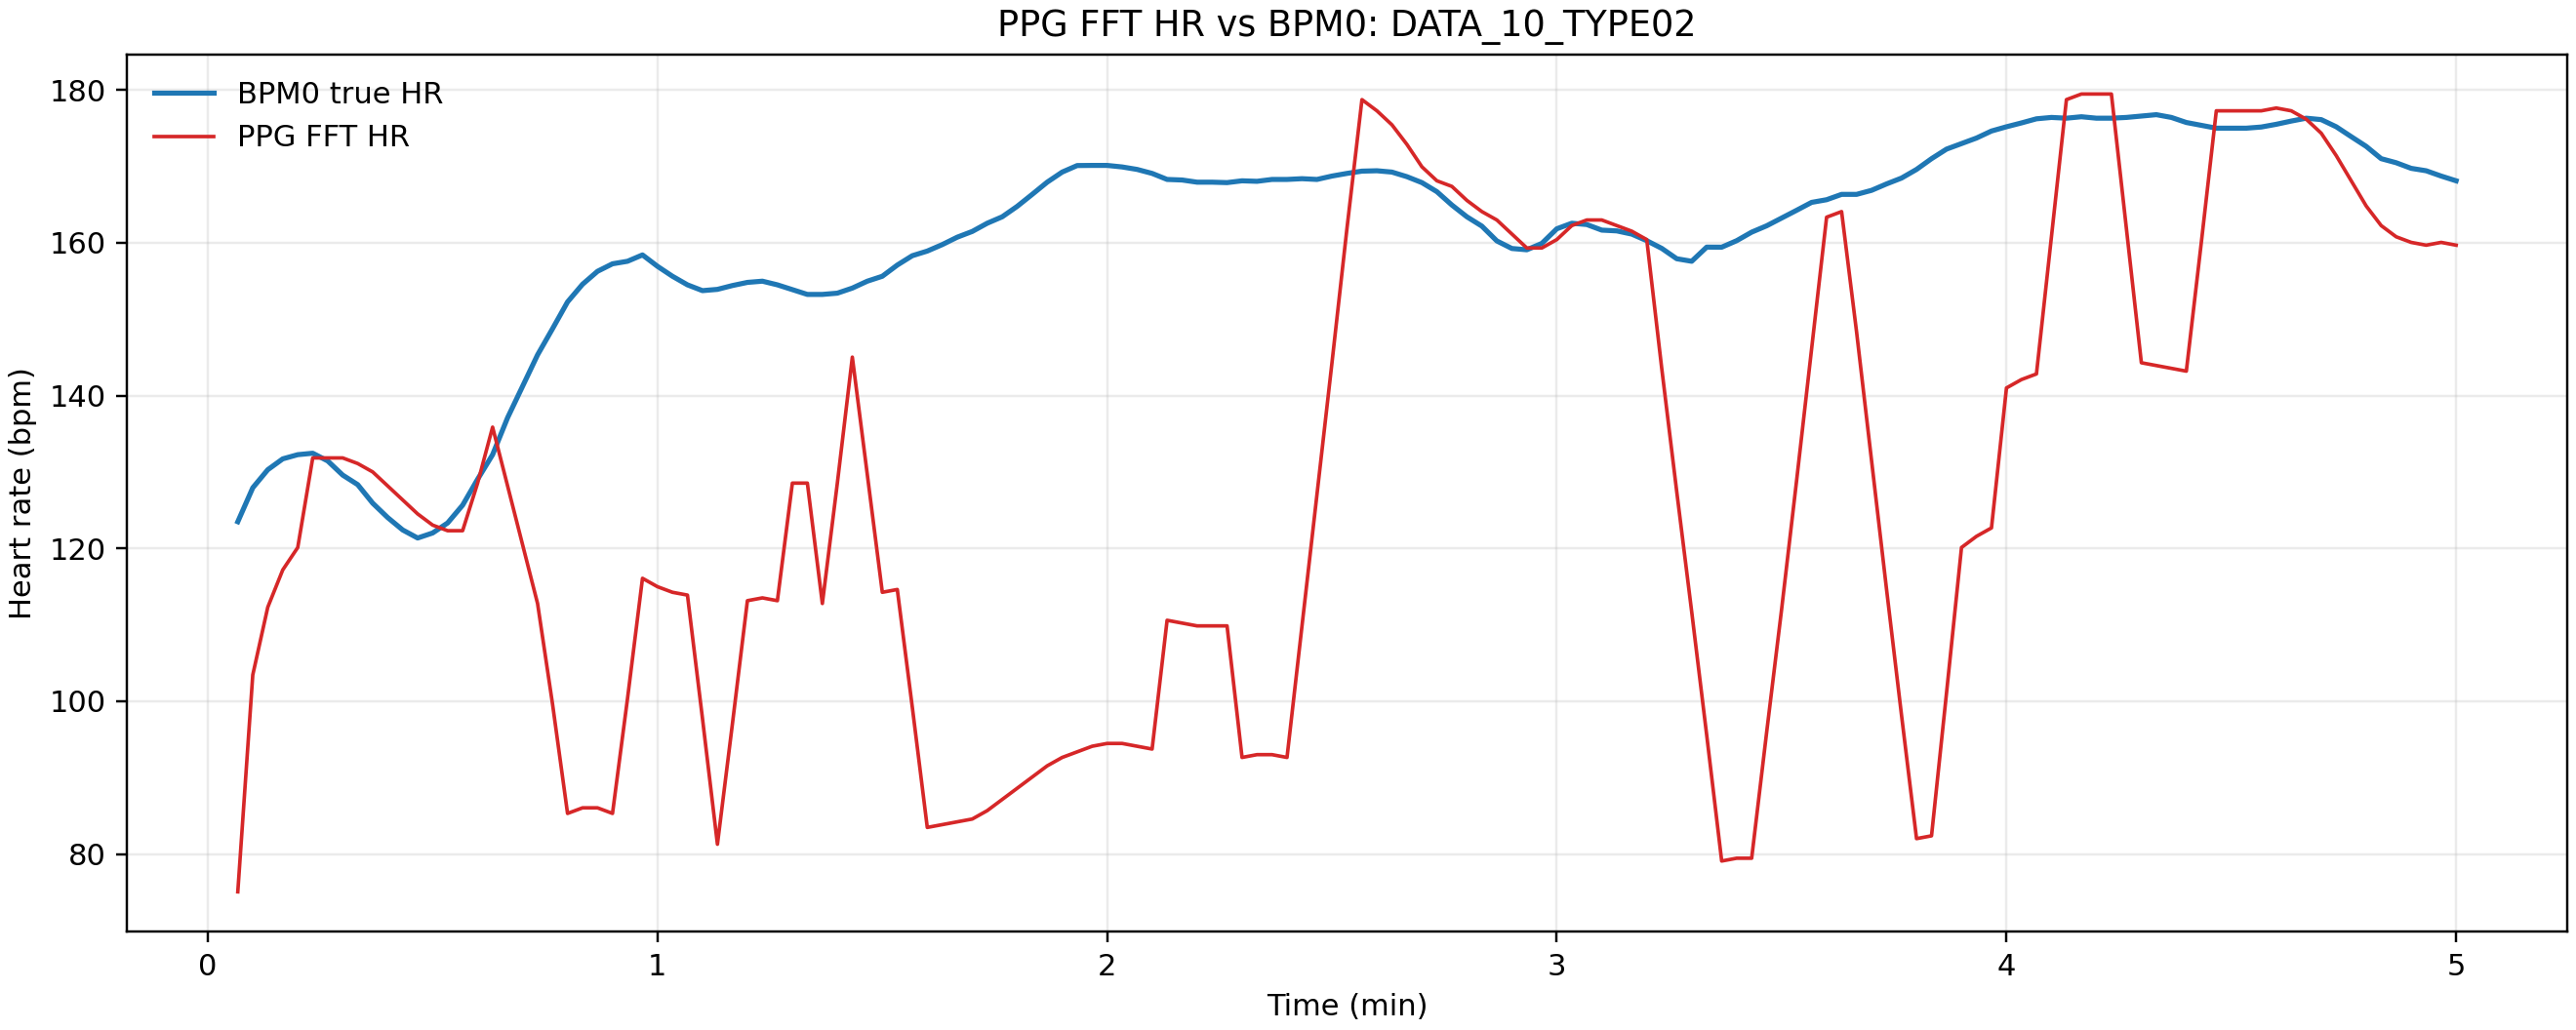

Saved: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denosing_notebook/plots/DATA_10_TYPE02_hr_true_vs_ppg_fft.png


In [5]:
PLOT_RECORD = "DATA_10_TYPE02"
record_df = windows[windows["record"] == PLOT_RECORD].copy()

fig, ax = plt.subplots(figsize=(12, 4.8), constrained_layout=True)
ax.plot(record_df["center_time_s"] / 60.0, record_df["hr_true_bpm"], label="BPM0 true HR", color="#1f77b4", linewidth=1.7)
ax.plot(record_df["center_time_s"] / 60.0, record_df["ppg_fft_hr_est_bpm"], label="PPG FFT HR", color="#d62728", linewidth=1.2)
ax.set_title(f"PPG FFT HR vs BPM0: {PLOT_RECORD}")
ax.set_xlabel("Time (min)")
ax.set_ylabel("Heart rate (bpm)")
ax.grid(True, alpha=0.25)
ax.legend(frameon=False)

timeseries_path = PLOTS_DIR / f"{PLOT_RECORD}_hr_true_vs_ppg_fft.png"
fig.savefig(timeseries_path, dpi=220)
plt.close(fig)

display(Image(filename=str(timeseries_path), width=950))
print("Saved:", timeseries_path)

## 5. Correlation 

The horizontal axis represents the ideal heart rate (BPM0), and the vertical axis represents the estimated heart rate using PPG FFT. The black diagonal line indicates an ideal estimate.

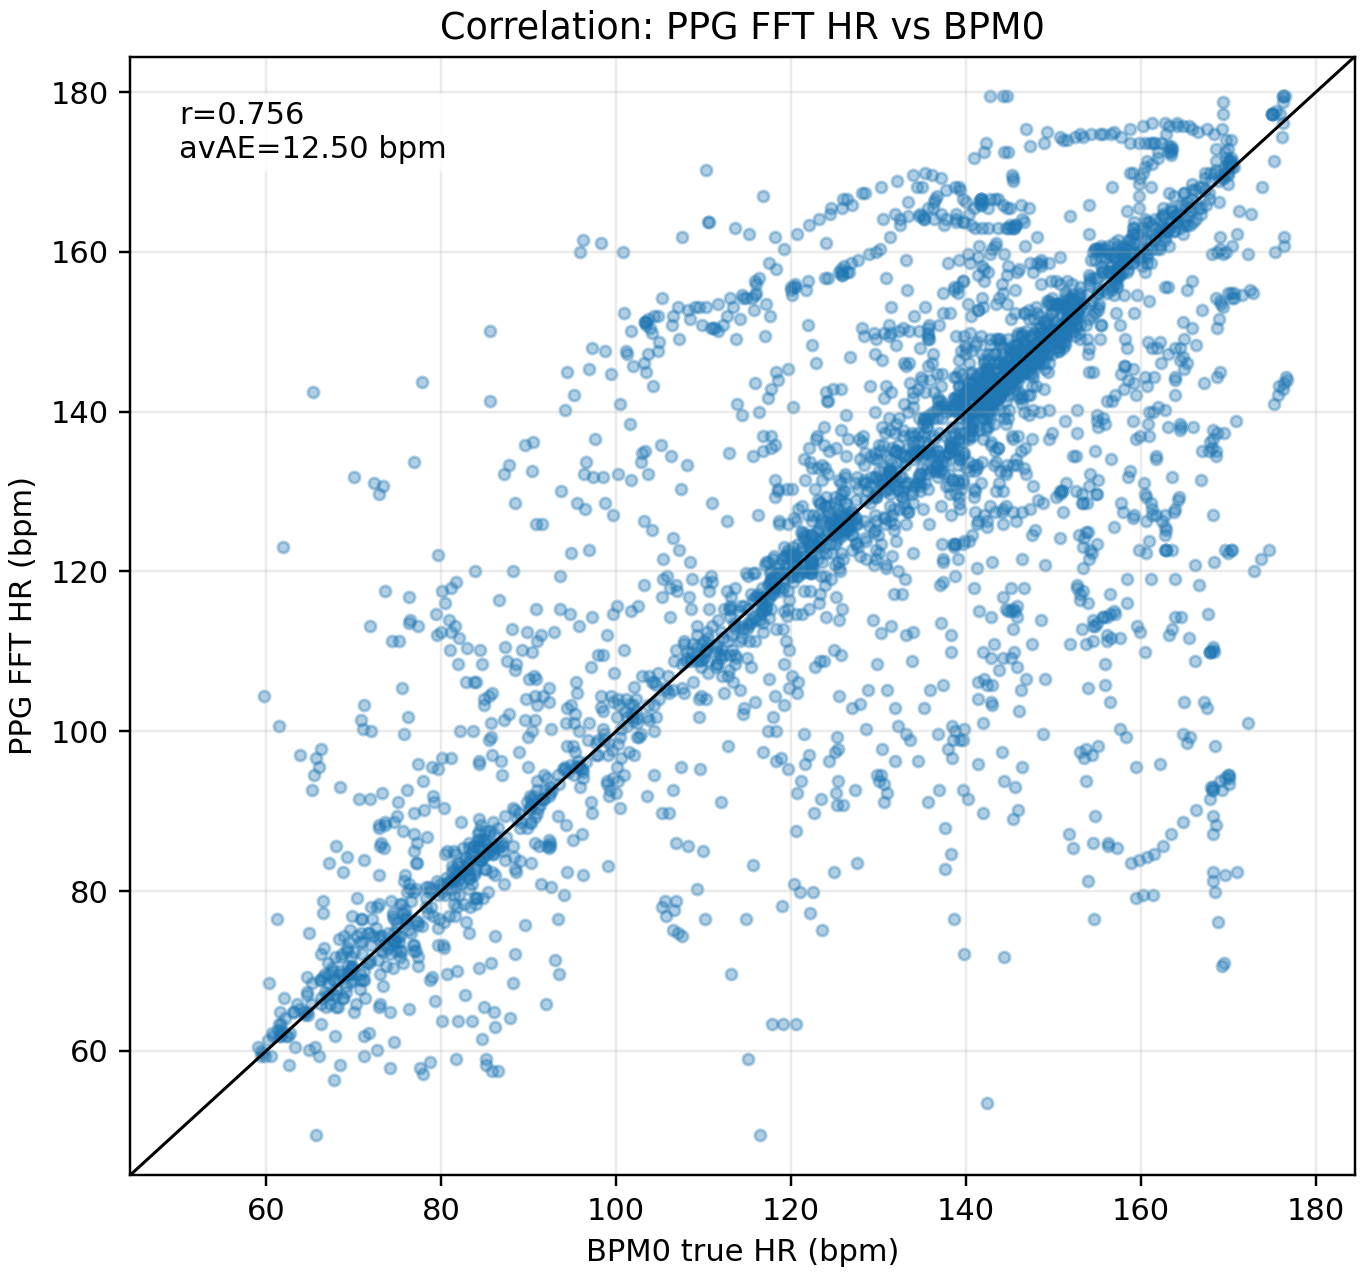

Saved: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denosing_notebook/plots/correlation_ppg_fft_vs_bpm0.png


In [6]:
valid = windows[["hr_true_bpm", "ppg_fft_hr_est_bpm"]].dropna()
overall = metrics[(metrics["record"] == "ALL_DATABASE") & (metrics["method"] == "PPG FFT")].iloc[0]

fig, ax = plt.subplots(figsize=(6.2, 5.8), constrained_layout=True)
ax.scatter(valid["hr_true_bpm"], valid["ppg_fft_hr_est_bpm"], s=13, alpha=0.35, color="#1f77b4")
lo = float(np.nanmin(valid.to_numpy()) - 5)
hi = float(np.nanmax(valid.to_numpy()) + 5)
ax.plot([lo, hi], [lo, hi], color="black", linewidth=1.0)
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_title("Correlation: PPG FFT HR vs BPM0")
ax.set_xlabel("BPM0 true HR (bpm)")
ax.set_ylabel("PPG FFT HR (bpm)")
ax.grid(True, alpha=0.25)
ax.text(
    0.04,
    0.96,
    f"r={overall['pearson_r']:.3f}\navAE={overall['mae_bpm']:.2f} bpm",
    transform=ax.transAxes,
    va="top",
    bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.85, "edgecolor": "none"},
)

corr_path = PLOTS_DIR / "correlation_ppg_fft_vs_bpm0.png"
fig.savefig(corr_path, dpi=220)
plt.close(fig)

display(Image(filename=str(corr_path), width=720))
print("Saved:", corr_path)

## 6. Bland-Altman Plot

The horizontal axis represents the mean of the estimated heart rate and the actual heart rate, and the vertical axis represents the estimation error `HR_est - BPM0`. The red line represents bias, and the black dashed line represents the 95% limits of agreement.

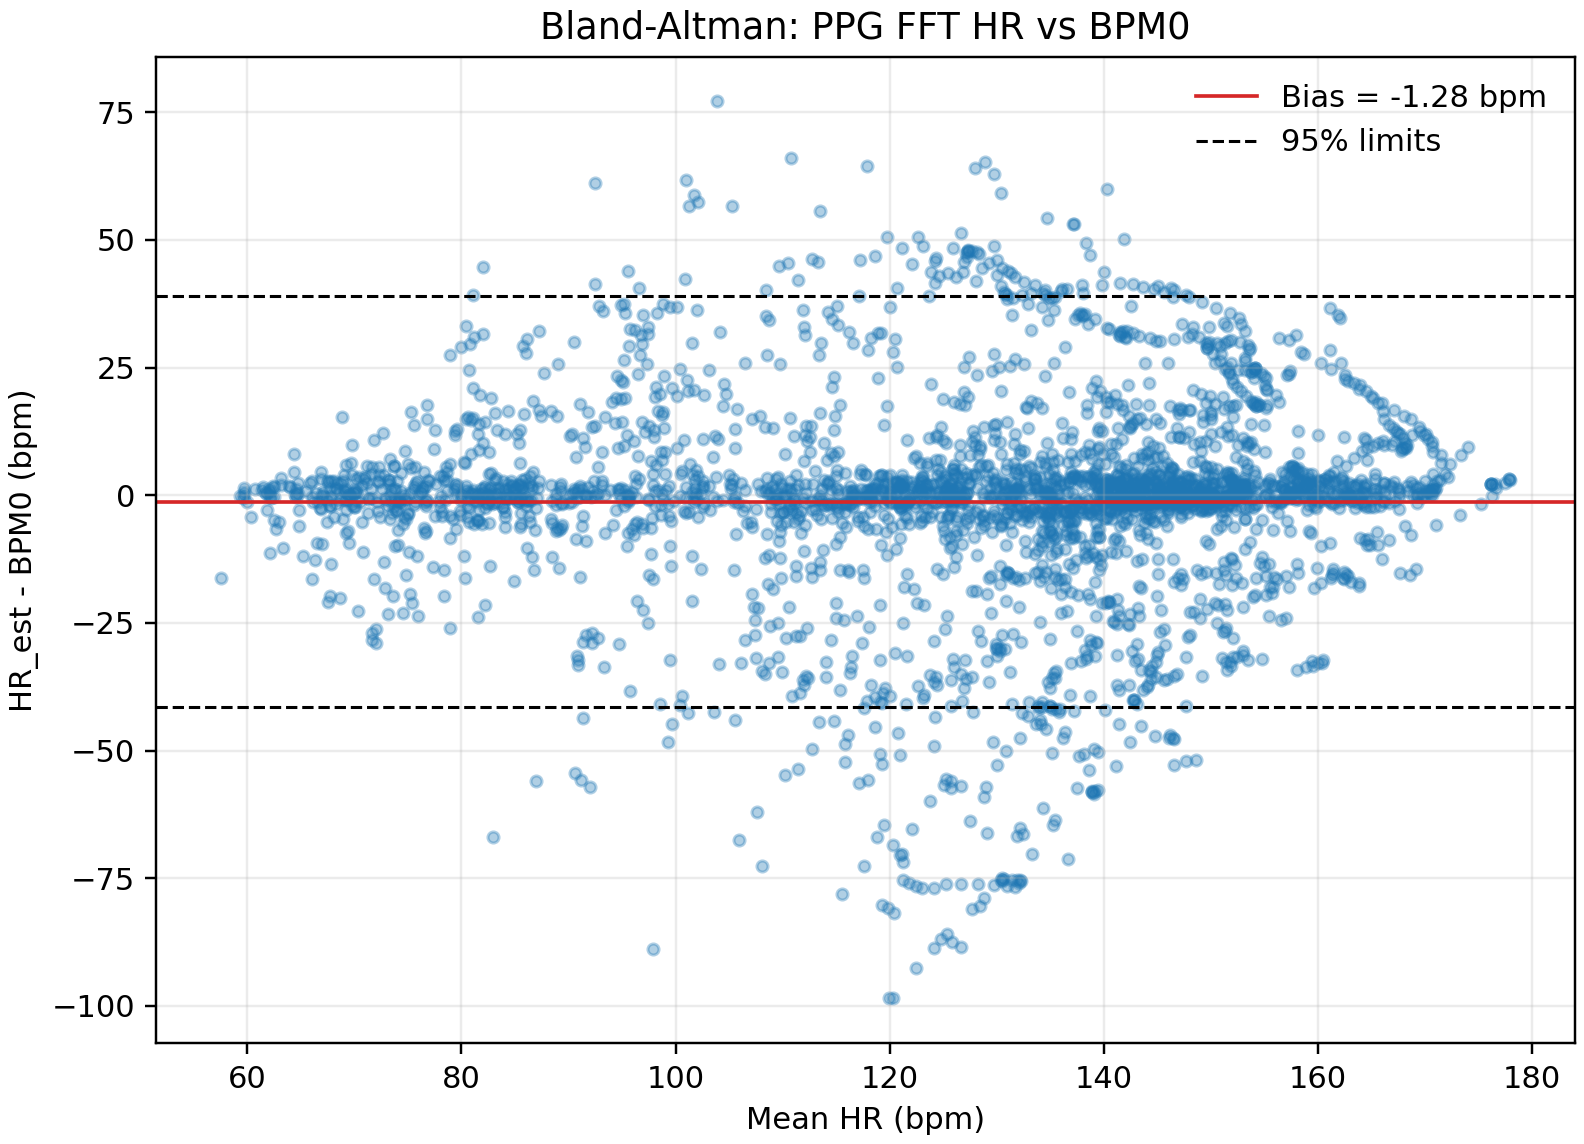

Saved: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denosing_notebook/plots/bland_altman_ppg_fft_vs_bpm0.png


In [7]:
mean_hr = valid.mean(axis=1)
diff_hr = valid["ppg_fft_hr_est_bpm"] - valid["hr_true_bpm"]
bias = float(overall["bias_bpm"])
lower = float(overall["bland_altman_lower_bpm"])
upper = float(overall["bland_altman_upper_bpm"])

fig, ax = plt.subplots(figsize=(7.2, 5.2), constrained_layout=True)
ax.scatter(mean_hr, diff_hr, s=13, alpha=0.35, color="#1f77b4")
ax.axhline(bias, color="#d62728", linewidth=1.2, label=f"Bias = {bias:.2f} bpm")
ax.axhline(lower, color="black", linestyle="--", linewidth=1.0, label="95% limits")
ax.axhline(upper, color="black", linestyle="--", linewidth=1.0)
ax.set_title("Bland-Altman: PPG FFT HR vs BPM0")
ax.set_xlabel("Mean HR (bpm)")
ax.set_ylabel("HR_est - BPM0 (bpm)")
ax.grid(True, alpha=0.25)
ax.legend(frameon=False)

ba_path = PLOTS_DIR / "bland_altman_ppg_fft_vs_bpm0.png"
fig.savefig(ba_path, dpi=220)
plt.close(fig)

display(Image(filename=str(ba_path), width=760))
print("Saved:", ba_path)

## 7. Output

In [8]:
print("Metric table:", OUTDIR / "ppg_fft_avAE_avRE_sdAE_table.csv")
print("Window-level HR:", OUTDIR / "ppg_fft_hr_windows.csv")
print("Baseline metrics:", OUTDIR / "ppg_fft_metrics.csv")
print("Plots directory:", PLOTS_DIR)

Metric table: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denosing_notebook/ppg_fft_avAE_avRE_sdAE_table.csv
Window-level HR: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denosing_notebook/ppg_fft_hr_windows.csv
Baseline metrics: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denosing_notebook/ppg_fft_metrics.csv
Plots directory: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denosing_notebook/plots
